The constant hypothesis that best approximates f in the average sense: y = 41.5705
The linear hypothesis that best approximates f in the average sense: y = -3.8300x + 21.1509

Bias and Variance components:
H0 (Constant Model) - Bias: 1426.8790, Variance: 403.9982, E_out: 1830.8772
H1 (Linear Model) - Bias: 1303.4415, Variance: 2370.7470, E_out: 3674.1885

Conclusion: Constant class of hypotheses(H₀) is more appropriate for prediction


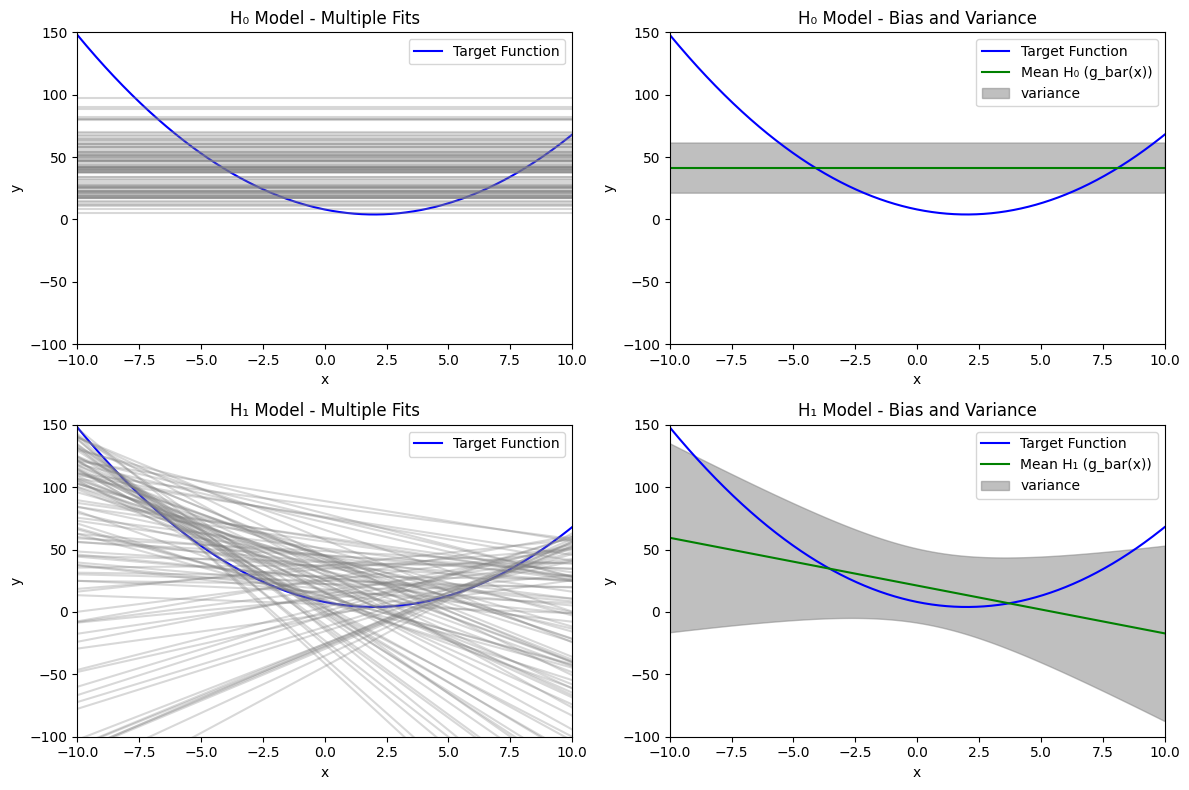

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


# Target function without noise
def target_function(x):
    #noise = np.random.normal(0, 0.2, size=x.shape)
    return (x - 2) ** 2 + 4

# Target function with noise for sampling
def target_function_noise(x):
    noise = np.random.normal(0, 0.2, size=x.shape)
    return (x - 2) ** 2 + 4 + noise

# Computing hypothesis that minimizes the in-sample error for constant model H0
def const_H0(train_y):
    return np.mean(train_y)

# Computing hypothesis for linear model H1.
def linear_H1(train_x, train_y):
    model = LinearRegression()
    model.fit(train_x.reshape(-1, 1), train_y)
    return model.coef_[0], model.intercept_

# Simulation parameters
num_experiments = 100  # Number of dataset samples
num_points = 3  # Number of training points per dataset 

# Computing true target function
x_test = np.linspace(-10, 10, 1000) 
y_true = target_function(x_test)  
 

H0_predictions = []
H1_predictions = []

l_a_H1 = []
l_b_H1 = []

for _ in range(num_experiments):
    train_x = np.random.uniform(-10, 10, num_points)
    train_y = target_function_noise(train_x)
    
    # Computing constant model prediction (H0)
    b_H0 = const_H0(train_y)
    H0_predictions.append(b_H0 * np.ones_like(x_test))
    
    # Computing linear model prediction (H1)
    a_H1, b_H1 = linear_H1(train_x, train_y)
    l_a_H1.append(a_H1)
    l_b_H1.append(b_H1)
    H1_predictions.append(a_H1 * x_test + b_H1)
        

# Convert to NumPy arrays
H0_predictions = np.array(H0_predictions)
H1_predictions = np.array(H1_predictions)


mean_H0 = np.mean(H0_predictions, axis=0) #g_bar_x_H0 
var_H0 = np.var(H0_predictions, axis=0)

mean_H1 = np.mean(H1_predictions, axis=0) #g_bar_x_H1 
var_H1 = np.var(H1_predictions, axis=0)



# Computing bias and variance for each model
bias_H0_x = np.mean((mean_H0 - y_true) ** 2) 
var_H0_x = np.mean(var_H0)

bias_H1_x = np.mean((mean_H1 - y_true) ** 2)
var_H1_x = np.mean(var_H1)

# Computing expected out-of-sample error
E_out_H0 = bias_H0_x + var_H0_x
E_out_H1 = bias_H1_x + var_H1_x

# Computing the slope and intercept of the best fit linear hypothesis
mean_a_H1 = np.mean(l_a_H1)  
mean_b_H1 = np.mean(l_b_H1) 


# Printing results
print(f'The constant hypothesis that best approximates f in the average sense: y = {np.mean(mean_H0):.4f}')
print(f'The linear hypothesis that best approximates f in the average sense: y = {mean_a_H1:.4f}x + {mean_b_H1:.4f}')
print( )
print("Bias and Variance components:")
print(f"H0 (Constant Model) - Bias: {bias_H0_x:.4f}, Variance: {var_H0_x:.4f}, E_out: {E_out_H0:.4f}")
print(f"H1 (Linear Model) - Bias: {bias_H1_x:.4f}, Variance: {var_H1_x:.4f}, E_out: {E_out_H1:.4f}")
print( )
if E_out_H0 < E_out_H1:
    print("Conclusion: Constant class of hypotheses(H₀) is more appropriate for prediction")
else:
    print("Conclusion: Constant class of hypotheses(H₁) is more appropriate for prediction")


# Plots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# H0 Model
axs[0, 0].plot(x_test, y_true, label="Target Function", color='blue')
for i in range(100): 
    axs[0, 0].plot(x_test, H0_predictions[i], color='gray', alpha=0.3)
axs[0, 0].set_title("H₀ Model - Multiple Fits")
axs[0, 0].set_ylim(-100, 150)
axs[0, 0].set_xlim(-10, 10)
axs[0, 0].set_xlabel("x")
axs[0, 0].set_ylabel("y")

# H0 Model (with variance and g_bar)
axs[0, 1].plot(x_test, y_true, label="Target Function", color='blue')
axs[0, 1].plot(x_test, mean_H0, label="Mean H₀ (g_bar(x))", color='green')
axs[0, 1].fill_between(x_test, mean_H0 - np.sqrt(var_H0), mean_H0 + np.sqrt(var_H0), label = "variance", color='gray', alpha=0.5)
axs[0, 1].set_title("H₀ Model - Bias and Variance")
axs[0, 1].set_ylim(-100, 150)
axs[0, 1].set_xlim(-10, 10)
axs[0, 1].set_xlabel("x")
axs[0, 1].set_ylabel("y")

# H1 Model
axs[1, 0].plot(x_test, y_true, label="Target Function", color='blue')
for i in range(100):  
    axs[1, 0].plot(x_test, H1_predictions[i], color='gray', alpha=0.3)
axs[1, 0].set_title("H₁ Model - Multiple Fits")
axs[1, 0].set_ylim(-100, 150)
axs[1, 0].set_xlim(-10, 10)
axs[1, 0].set_xlabel("x")
axs[1, 0].set_ylabel("y")

# H1 Model (with variance and g_bar)
axs[1, 1].plot(x_test, y_true, label="Target Function", color='blue')
axs[1, 1].plot(x_test, mean_H1, label="Mean H₁ (g_bar(x))", color='green')
axs[1, 1].fill_between(x_test, mean_H1 - np.sqrt(var_H1), mean_H1 + np.sqrt(var_H1), label = "variance", color='gray', alpha=0.5)
axs[1, 1].set_title("H₁ Model - Bias and Variance")
axs[1, 1].set_ylim(-100, 150)
axs[1, 1].set_xlim(-10, 10)
axs[1, 1].set_xlabel("x")
axs[1, 1].set_ylabel("y")

for ax in axs.flat:
    ax.legend()

plt.tight_layout()
plt.show()



